***
# KWS (keyword spotting) and applying for EFR32FG24 Silicon lab kit
***
- peiman edalatjoo -  *** KWS_ver01.02 *** - winter 2025 - HKA
- Any correction, enhancement, or guidance reported to peiman.edalatjoo@proton.me or edpe1011@h-ka.de will be greatly appreciated.
- To run this code error-free, please read the README file first.
***
Description:
An audio dataset of spoken words designed to help train and evaluate keyword spotting systems. Its primary goal is to provide a way to build and test small models that detect when a single word is spoken, from a set of ten target words, with as few false positives as possible from background noise or unrelated speech. Note that in the train and validation set, the label "unknown" is much more prevalent than the labels of the target words or background noise. One difference from the release version is the handling of silent segments. While in the test set the silence segments are regular 1 second files, in the training they are provided as long segments under "background_noise" folder. Here we split these background noise into 1 second clips, and also keep one of the files for the validation set. https://www.tensorflow.org/datasets/catalog/speech_commands

- peiman edalatjoo -  *** KWS_ver01.02 ***
- Any correction, enhancement, or guidance reported to peiman.edalatjoo@proton.me or edpe1011@h-ka.de will be greatly appreciated.
- To run this code error-free, please read the README file first.

# 1- Import datasets and evaluate them
## 1.1: Import the Dataset
We will use TensorFlow Datasets (tensorflow_datasets) to load the Google Speech Commands dataset. Here's the code to load and inspect the dataset:

In [10]:
import tensorflow as tf
import tensorflow_datasets as tfds
import os
import pickle


Explanations about pickle: 

Below the info object returned by tfds.load() contains metadata about the dataset, such as label names, sample rate, and other useful information.
This info object is not a simple data type (like a string or list), but a complex Python object.
To save this object for later use (so you don’t have to reload and reconstruct it every time), pickle.dump() is used to serialize this information and write it to a file while pickle.load is used to read this info from a file.
pickle.load restors the info object exactly as it was.

In [11]:

def save_dataset(dataset, path):
    tf.data.experimental.save(dataset, path)

def load_dataset(path):
    return tf.data.experimental.load(path)

# Paths to save datasets
save_dir = 'saved_speech_commands'
train_path = os.path.join(save_dir, 'train')
val_path = os.path.join(save_dir, 'validation')
test_path = os.path.join(save_dir, 'test')
info_path = os.path.join(save_dir, 'info.pkl')

# Create save directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Check if saved datasets exist
if all(os.path.exists(p) for p in [train_path, val_path, test_path, info_path]):
    print('Loading datasets from disk...')
    train_dataset = load_dataset(train_path)
    validation_dataset = load_dataset(val_path)
    test_dataset = load_dataset(test_path)
    with open(info_path, 'rb') as f:
        info = pickle.load(f)
else:
    print('Loading datasets from TensorFlow Datasets...')
    dataset, info = tfds.load('speech_commands', with_info=True, as_supervised=True)
    #as_supervised=True to get (input, label) pairs instead of a dictionary.
    #return additional metadata (info) about the dataset if you set with_info=True
    train_dataset = dataset['train']
    validation_dataset = dataset['validation']
    test_dataset = dataset['test']
    save_dataset(train_dataset, train_path)
    save_dataset(validation_dataset, val_path)
    save_dataset(test_dataset, test_path)
    with open(info_path, 'wb') as f:
        pickle.dump(info, f)
    print('Datasets saved to disk.')

print(f"Number of training samples: {len(list(train_dataset))}")
print(f"Number of validation samples: {len(list(validation_dataset))}")
print(f"Number of test samples: {len(list(test_dataset))}")
print(f"Available labels: {info.features['label'].names}")
print("Dataset Info:")
print(info)
'''total = train_dataset.shuffle(10000, seed=42)
val_size = 5000  # e.g., take 5k samples for validation

validation_dataset = total.take(val_size)
train_dataset = total.skip(val_size)

train_dataset_batched = train_dataset.map(...).batch(...).prefetch(...)
validation_dataset_batched = validation_dataset.map(...).batch(...).prefetch(...)

'''

Loading datasets from disk...
Number of training samples: 106497
Number of validation samples: 121
Number of test samples: 4890
Available labels: ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes', '_silence_', '_unknown_']
Dataset Info:
tfds.core.DatasetInfo(
    name='speech_commands',
    full_name='speech_commands/0.0.3',
    description="""
    An audio dataset of spoken words designed to help train and evaluate keyword
    spotting systems. Its primary goal is to provide a way to build and test small
    models that detect when a single word is spoken, from a set of ten target words,
    with as few false positives as possible from background noise or unrelated
    speech. Note that in the train and validation set, the label "unknown" is much
    more prevalent than the labels of the target words or background noise. One
    difference from the release version is the handling of silent segments. While in
    the test set the silence segments are regular 1 seco

'total = train_dataset.shuffle(10000, seed=42)\nval_size = 5000  # e.g., take 5k samples for validation\n\nvalidation_dataset = total.take(val_size)\ntrain_dataset = total.skip(val_size)\n\ntrain_dataset_batched = train_dataset.map(...).batch(...).prefetch(...)\nvalidation_dataset_batched = validation_dataset.map(...).batch(...).prefetch(...)\n\n'

Shape and Datatype of downloaded dtatsets

In [12]:
# Load dataset and print audio shape with label name
# Load label names from info.pkl
with open('saved_speech_commands/info.pkl', 'rb') as f:
    info = pickle.load(f)
label_names = info.features['label'].names

print("Training dataset datatypes check:")   
for x in train_dataset.take(1):
    print(type(x))              # <class 'tuple'>
    print(type(x[0]), x[0].shape, x[0].dtype)  # audio tensor
    print(type(x[1]), x[1].numpy())            # label tensor
print("Validation dataset datatypes check:")    
for x in validation_dataset.take(1):
    print(type(x))              # <class 'tuple'>
    print(type(x[0]), x[0].shape, x[0].dtype)  # audio tensor
    print(type(x[1]), x[1].numpy())            # label tensor
print("Test dataset datatypes check:")
for x in test_dataset.take(1):
    print(type(x))              # <class 'tuple'>
    print(type(x[0]), x[0].shape, x[0].dtype)  # audio tensor
    print(type(x[1]), x[1].numpy())            # label tensor 




Training dataset datatypes check:
<class 'tuple'>
<class 'tensorflow.python.framework.ops.EagerTensor'> (16000,) <dtype: 'int16'>
<class 'tensorflow.python.framework.ops.EagerTensor'> 4
Validation dataset datatypes check:
<class 'tuple'>
<class 'tensorflow.python.framework.ops.EagerTensor'> (16000,) <dtype: 'int16'>
<class 'tensorflow.python.framework.ops.EagerTensor'> 10
Test dataset datatypes check:
<class 'tuple'>
<class 'tensorflow.python.framework.ops.EagerTensor'> (16000,) <dtype: 'int16'>
<class 'tensorflow.python.framework.ops.EagerTensor'> 7


### 1-2 Evaluating - Processing data

- Dataset quility

In [13]:
import numpy as np

def print_audio_sample_quality(dataset, label_names):
    silent_counts = {name: 0 for name in label_names}
    flat_counts = {name: 0 for name in label_names}
    nan_counts = {name: 0 for name in label_names}
    total_counts = {name: 0 for name in label_names}
    total_samples = 0
    for audio, label in dataset:
        audio_np = audio.numpy() if hasattr(audio, 'numpy') else np.array(audio)
        label_name = label_names[label.numpy()]
        total_counts[label_name] += 1
        total_samples += 1
        if np.all(audio_np == 0): # check if all values are zero (silent)
            silent_counts[label_name] += 1
        if np.all(audio_np == audio_np[0]): # check if all values are the same (flat)
            flat_counts[label_name] += 1
        if np.any(np.isnan(audio_np)) or np.any(np.isinf(audio_np)): # check for NaN (Not a numbe) or +/- Infinit values
            nan_counts[label_name] += 1
    print(f"Total samples in dataset: {total_samples}")
    print("Label\tTotal\tSilent\tFlat\tNaN/Inf")
    for name in label_names:
        print(f"{name}\t{total_counts[name]}\t{silent_counts[name]}\t{flat_counts[name]}\t{nan_counts[name]}")

# Example usage:
print("Train dataset sample quality:")
print_audio_sample_quality(train_dataset, label_names)
print("\nValidation dataset sample quality:")
print_audio_sample_quality(validation_dataset, label_names)
print("\nTest dataset sample quality:")
print_audio_sample_quality(test_dataset, label_names)
#print(f"Number of samples in train dataset: {len(list(train_dataset))}")


Train dataset sample quality:
Total samples in dataset: 106497
Label	Total	Silent	Flat	NaN/Inf
down	3917	0	0	0
go	3880	0	0	0
left	3801	0	0	0
no	3941	0	0	0
off	3745	0	0	0
on	3845	0	0	0
right	3778	0	0	0
stop	3872	0	0	0
up	3723	0	0	0
yes	4044	0	0	0
_silence_	668	0	0	0
_unknown_	67283	0	0	0

Validation dataset sample quality:
Total samples in dataset: 121
Label	Total	Silent	Flat	NaN/Inf
down	0	0	0	0
go	0	0	0	0
left	0	0	0	0
no	0	0	0	0
off	0	0	0	0
on	0	0	0	0
right	0	0	0	0
stop	0	0	0	0
up	0	0	0	0
yes	0	0	0	0
_silence_	121	0	0	0
_unknown_	0	0	0	0

Test dataset sample quality:
Total samples in dataset: 4890
Label	Total	Silent	Flat	NaN/Inf
down	406	0	0	0
go	402	0	0	0
left	412	0	0	0
no	405	0	0	0
off	402	0	0	0
on	396	0	0	0
right	396	0	0	0
stop	411	0	0	0
up	425	0	0	0
yes	419	0	0	0
_silence_	408	0	0	0
_unknown_	408	0	0	0


### - Shape of audio samples - Sampling Rate
As we see in the output of below code, just SR of training dataset varies from 16000 Hz (Note as we are samples are humance voice so according Nyquist rate, 16kz will fulfill to cover human voice range of frequency).

In [14]:
#print out min, max of the shape of audio samples for each dataset (train, validation, test)
def print_audio_shape_stats(dataset, dataset_name):
    shapes = [audio.shape for audio, _ in dataset]
    min_shape = min(shapes, key=lambda x: x[0])
    max_shape = max(shapes, key=lambda x: x[0])
    print(f"{dataset_name} dataset audio shape stats:")
    print(f"Min shape: {min_shape}")
    print(f"Max shape: {max_shape}")
print_audio_shape_stats(train_dataset, "Train")
print_audio_shape_stats(validation_dataset, "Validation")   
print_audio_shape_stats(test_dataset, "Test")

Train dataset audio shape stats:
Min shape: (3413,)
Max shape: (16000,)
Validation dataset audio shape stats:
Min shape: (16000,)
Max shape: (16000,)
Test dataset audio shape stats:
Min shape: (16000,)
Max shape: (16000,)



- ploting one non-16k and a 16khz of train and two random of the others to visualise amplitude 

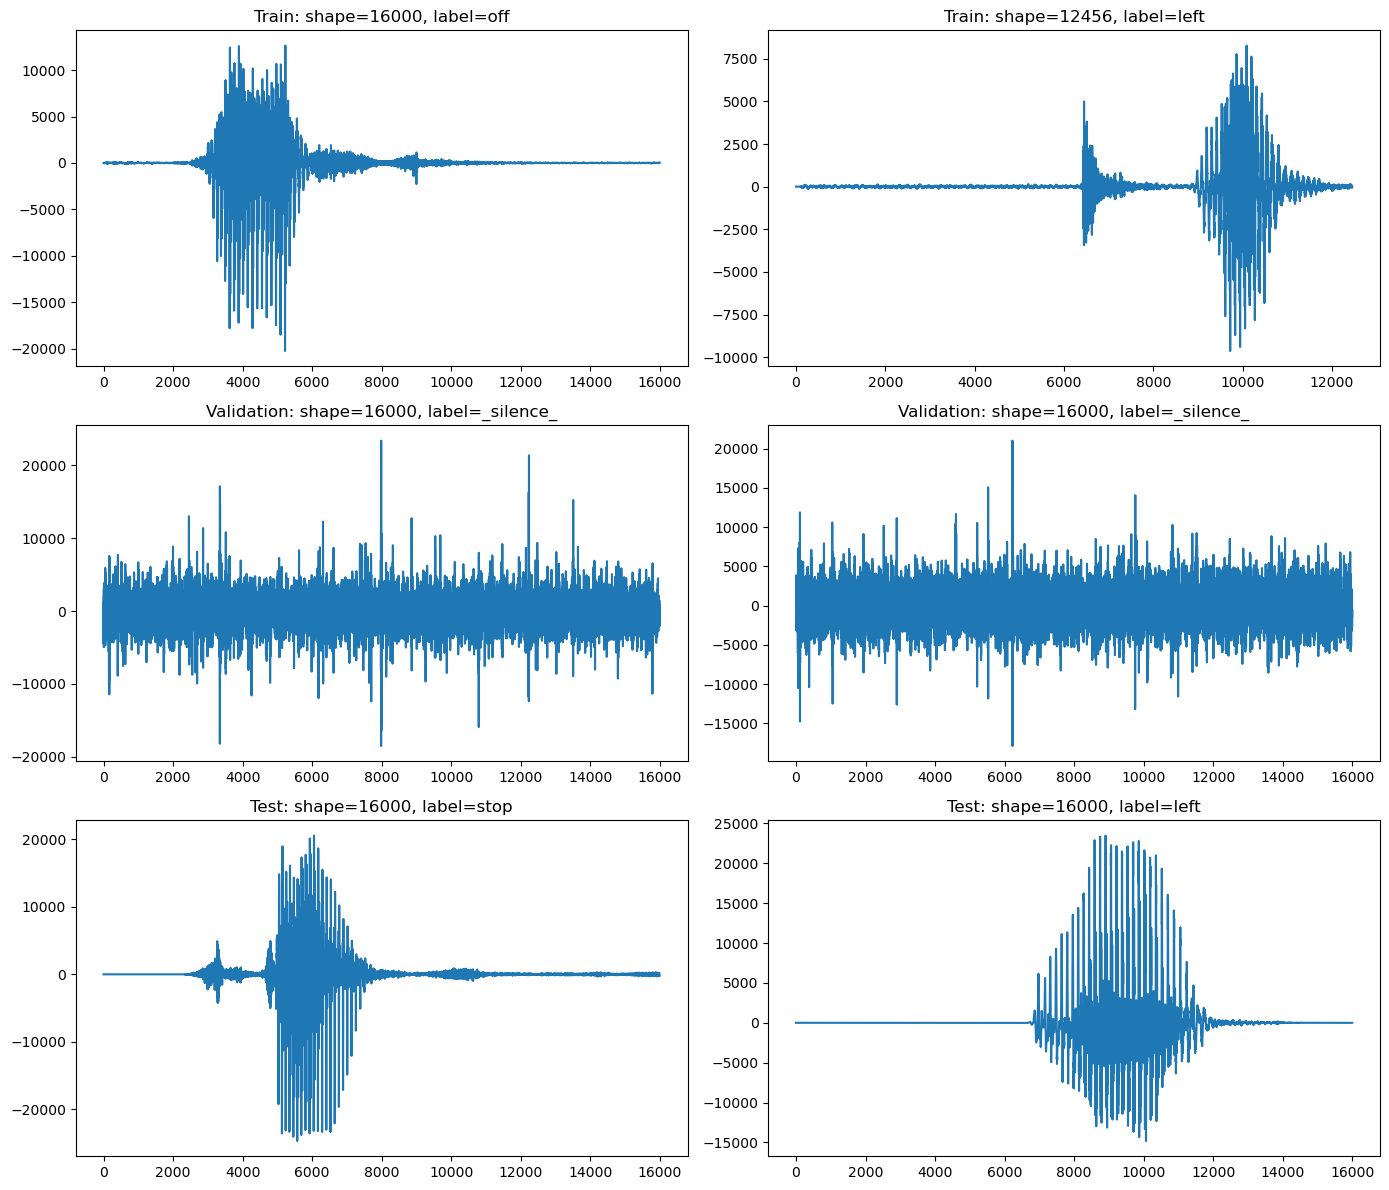

In [15]:

import matplotlib.pyplot as plt

# Helper to get one sample of a given length from a dataset
def get_sample_by_length(dataset, length, exclude=False):
    for audio, label in dataset:
        if (audio.shape[0] == length) != exclude:
            return audio.numpy(), label.numpy()
    return None, None

# Get one 16000-shape and one non-16000-shape from train_dataset
audio_16000, label_16000 = get_sample_by_length(train_dataset, 16000, exclude=False)
audio_non16000, label_non16000 = get_sample_by_length(train_dataset, 16000, exclude=True)

# Get two random samples from validation_dataset
val_samples = [(audio.numpy(), label.numpy()) for audio, label in validation_dataset.take(2)]

# Get two random samples from test_dataset
test_samples = [(audio.numpy(), label.numpy()) for audio, label in test_dataset.take(2)]


# Adjust to 3 rows and 2 columns: first row - training, second - validation, third - test
fig, axs = plt.subplots(3, 2, figsize=(14, 12))

# Training samples
axs[0, 0].plot(audio_16000)
axs[0, 0].set_title(f"Train: shape=16000, label={label_names[label_16000]}")
axs[0, 1].plot(audio_non16000)
axs[0, 1].set_title(f"Train: shape={audio_non16000.shape[0]}, label={label_names[label_non16000]}")

# Validation samples
axs[1, 0].plot(val_samples[0][0])
axs[1, 0].set_title(f"Validation: shape={val_samples[0][0].shape[0]}, label={label_names[val_samples[0][1]]}")
axs[1, 1].plot(val_samples[1][0])
axs[1, 1].set_title(f"Validation: shape={val_samples[1][0].shape[0]}, label={label_names[val_samples[1][1]]}")

# Test samples
axs[2, 0].plot(test_samples[0][0])
axs[2, 0].set_title(f"Test: shape={test_samples[0][0].shape[0]}, label={label_names[test_samples[0][1]]}")
axs[2, 1].plot(test_samples[1][0])
axs[2, 1].set_title(f"Test: shape={test_samples[1][0].shape[0]}, label={label_names[test_samples[1][1]]}")
# print the shape of an example of _unknown_ lable from training and validation datasets  

plt.tight_layout()
plt.show()

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split

X = []
y = []
desired_len = 16000  # or whatever fixed length you want

for audio, label in train_dataset:
    audio_np = audio.numpy()
    if len(audio_np) < desired_len:
        audio_np = np.pad(audio_np, (0, desired_len - len(audio_np)))
    else:
        audio_np = audio_np[:desired_len]
    X.append(audio_np)
    y.append(label.numpy())

X = np.array(X)
y = np.array(y)

# Now you can use train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

new_train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
new_validation_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))

In [ ]:
import pandas as pd

# Helper function to count label occurrences in a tf.data.Dataset

def count_labels(dataset, label_names):
    counts = {name: 0 for name in label_names}
    for _, label in dataset:
        label_idx = int(label.numpy())
        counts[label_names[label_idx]] += 1
    return counts

# Count labels in each dataset
train_counts = count_labels(new_train_dataset, label_names)
val_counts = count_labels(new_validation_dataset, label_names)
test_counts = count_labels(test_dataset, label_names)

# Create a DataFrame to display as a table
df_counts = pd.DataFrame({
    'Train': pd.Series(train_counts),
    'Validation': pd.Series(val_counts),
    'Test': pd.Series(test_counts)
}).fillna(0).astype(int)

# Add total row
df_counts.loc['Total'] = df_counts.sum()

print(df_counts)




           Train  Validation  Test
down        3525         392   406
go          3492         388   402
left        3421         380   412
no          3547         394   405
off         3370         375   402
on          3460         385   396
right       3400         378   396
stop        3485         387   411
up          3351         372   425
yes         3640         404   419
_silence_    601          67   408
_unknown_  60555        6728   408
Total      95847       10650  4890


printing 5 sample of each data sets

In [24]:
# Print the first 5 samples from the each  dataset
print("First 5 data in Traing Dataset:")
for audio, label in new_train_dataset.take(5):
    print(audio.shape, label.numpy(), label_names[label.numpy()])
print("Audio dtype:", audio.dtype)
print("First 5 data in Validation Dataset:")
for audio, label in new_validation_dataset.take(5):
    print(audio.shape, label.numpy(), label_names[label.numpy()])
print("Audio dtype:", audio.dtype)
print("First 5 data in Test Dataset:")
for audio, label in test_dataset.take(5):
    print(audio.shape, label.numpy(), label_names[label.numpy()])   
print("Audio dtype:", audio.dtype)
# print(f"Audio sample rate: {info.features['audio'].sample_rate}") 


First 5 data in Traing Dataset:
(16000,) 7 stop
(16000,) 1 go
(16000,) 0 down
(16000,) 11 _unknown_
(16000,) 11 _unknown_
Audio dtype: <dtype: 'int16'>
First 5 data in Validation Dataset:
(16000,) 11 _unknown_
(16000,) 11 _unknown_
(16000,) 11 _unknown_
(16000,) 11 _unknown_
(16000,) 11 _unknown_
Audio dtype: <dtype: 'int16'>
First 5 data in Test Dataset:
(16000,) 7 stop
(16000,) 2 left
(16000,) 6 right
(16000,) 8 up
(16000,) 5 on
Audio dtype: <dtype: 'int16'>


In [27]:
#print out min, max of the shape of audio samples for each dataset (train, validation, test)
def print_audio_shape_stats(dataset, dataset_name):
    shapes = [audio.shape for audio, _ in dataset]
    min_shape = min(shapes, key=lambda x: x[0])
    max_shape = max(shapes, key=lambda x: x[0])
    print(f"{dataset_name} dataset audio shape stats:")
    print(f"Min shape: {min_shape}")
    print(f"Max shape: {max_shape}")
print_audio_shape_stats(new_train_dataset, "Train")
print_audio_shape_stats(new_validation_dataset, "Validation")   
print_audio_shape_stats(test_dataset, "Test")

Train dataset audio shape stats:
Min shape: (16000,)
Max shape: (16000,)
Validation dataset audio shape stats:
Min shape: (16000,)
Max shape: (16000,)
Test dataset audio shape stats:
Min shape: (16000,)
Max shape: (16000,)


-  We observed that the shape of training datasets are not constant 16 khz as two others (test and validation)
-  lets see the Sample Rate Distribution of audio samples in training data sets.

Plotting audio length boxplot per label for training dataset...


C:\Users\Peyman\AppData\Local\Temp\ipykernel_11780\1553640557.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_names, showmeans=True)


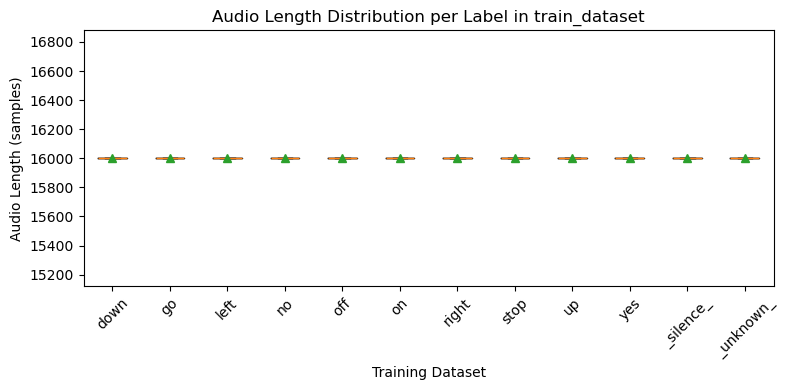

Plotting audio length boxplot per label for validation dataset...


C:\Users\Peyman\AppData\Local\Temp\ipykernel_11780\1553640557.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_names, showmeans=True)


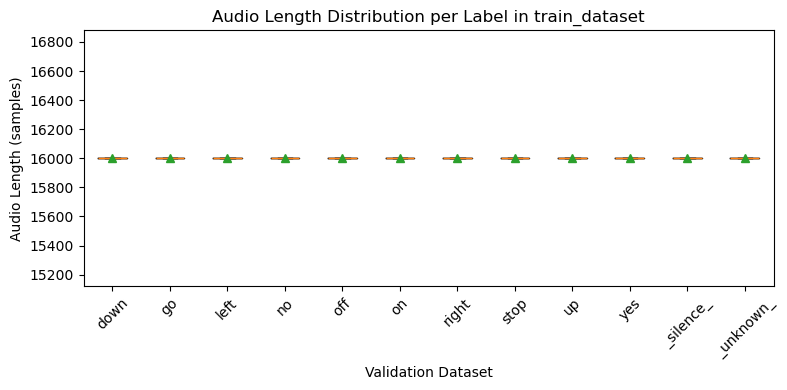

Plotting audio length boxplot per label for test dataset...


C:\Users\Peyman\AppData\Local\Temp\ipykernel_11780\1553640557.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_names, showmeans=True)


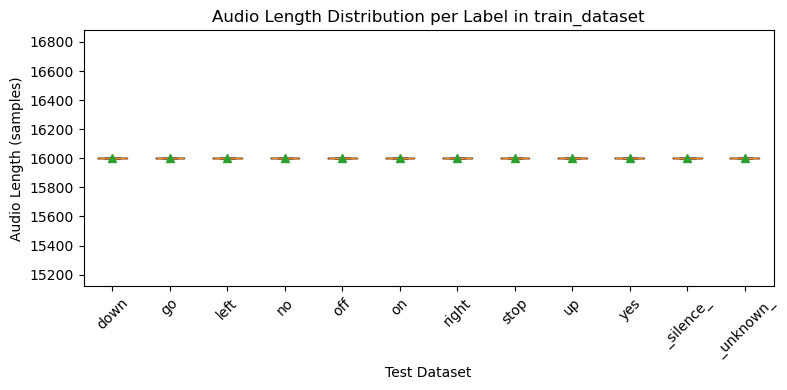

In [30]:
import matplotlib.pyplot as plt

def plot_audio_length_boxplot_per_label(dataset, label_names, dataset_name):
    import numpy as np
    lengths_per_label = {name: [] for name in label_names}
    for audio, label in dataset:
        label_name = label_names[label.numpy()]
        lengths_per_label[label_name].append(audio.shape[0])
    data = [lengths_per_label[name] for name in label_names]
    plt.figure(figsize=(8, 4))
    plt.boxplot(data, labels=label_names, showmeans=True)
    plt.xlabel(dataset_name)
    plt.ylabel('Audio Length (samples)')
    plt.title('Audio Length Distribution per Label in train_dataset')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Example usage:
print("Plotting audio length boxplot per label for training dataset...")    
plot_audio_length_boxplot_per_label(new_train_dataset, label_names, 'Training Dataset')
print("Plotting audio length boxplot per label for validation dataset...")    
plot_audio_length_boxplot_per_label(new_validation_dataset, label_names, 'Validation Dataset')
print("Plotting audio length boxplot per label for test dataset...")    
plot_audio_length_boxplot_per_label(test_dataset, label_names, 'Test Dataset')



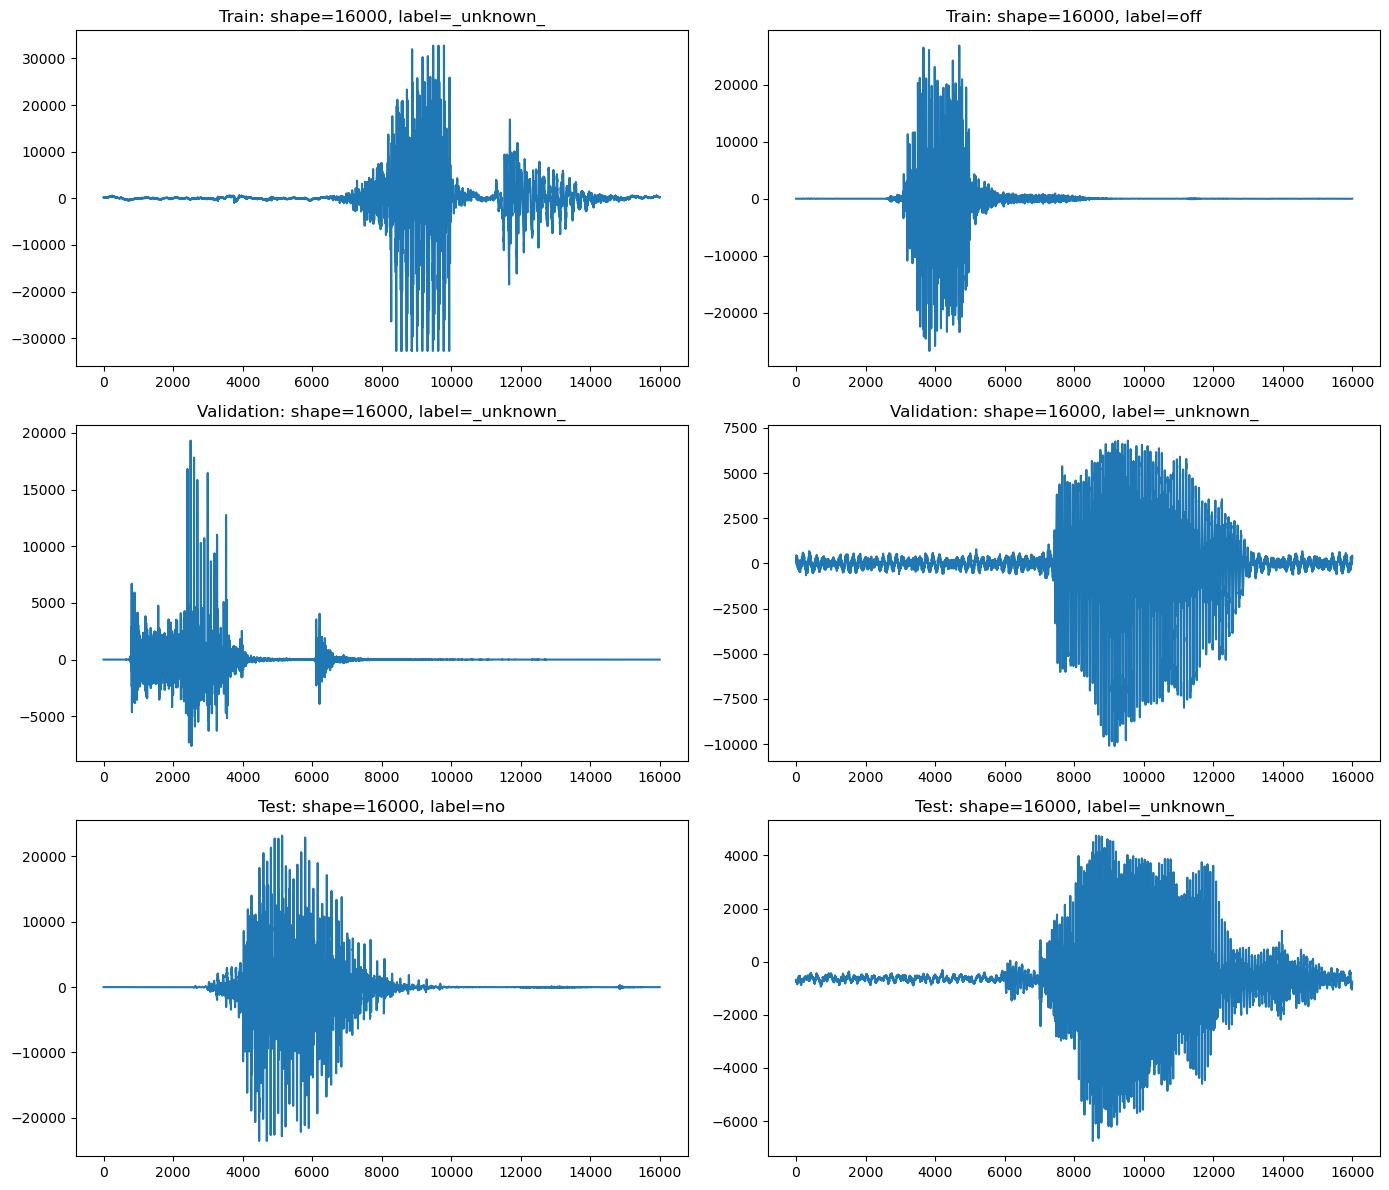

In [36]:

import matplotlib.pyplot as plt
import numpy as np

def plot_two_samples_per_dataset(datasets, dataset_names, label_names):
    """
    Plots 2 random samples from each dataset in a 3x2 subplot grid.
    Args:
        datasets: list of tf.data.Dataset objects (length 3)
        dataset_names: list of str, names for each dataset (length 3)
        label_names: list of label names for decoding label indices
    """
    fig, axs = plt.subplots(3, 2, figsize=(14, 12))
    for row, (ds, name) in enumerate(zip(datasets, dataset_names)):
        # Convert dataset to list for random sampling
        samples = list(ds)
        idxs = np.random.choice(len(samples), 2, replace=False)
        for col, idx in enumerate(idxs):
            audio, label = samples[idx]
            axs[row, col].plot(audio.numpy())
            axs[row, col].set_title(f"{name}: shape={audio.shape[0]}, label={label_names[label.numpy()]}")
    plt.tight_layout()
    plt.show()

# Example usage:
plot_two_samples_per_dataset(
    [new_train_dataset, new_validation_dataset, test_dataset],
    ['Train', 'Validation', 'Test'],
    label_names
)

# 2-Preprocess the Data
We need to normalize the audio data and ensure all samples are of consistent length in order to go through CNN as arule of thumb. Also From previous codes we concluded that training dada sets has some variation in SR (sampling rate).
we are going to tru diffrent preprocessing over it. Here are zero pading in order to make it fix to 16000 rate; ready to CNN which demands fix dimention. 

### 2-1 Normalised and zero pading

In [ ]:

def preprocess_audio(audio, label):
    # Normalize audio to range [-1, 1]
    audio = tf.cast(audio, tf.float32) / tf.int16.max
    return audio, label

# Apply preprocessing to the datasets
#  tf.image.resize_with_crop_or_pad expects a 3D or 4D tensor (image), /
# but audio is a 1D tensor. For 1D audio, use tf.cond with tf.shape or tf.pad/tf.slice directly.
# It is a good practice to keep the original/raw datasets unchanged and save the preprocessed datasets in new variables.
# This allows you to reuse the raw data for different preprocessing or experiments.

train_dataset_Nor_Padded= new_train_dataset.map(preprocess_audio)
validation_dataset_Nor_Padded = new_validation_dataset.map(preprocess_audio)
test_dataset_Nor_Padded = test_dataset.map(preprocess_audio)

 

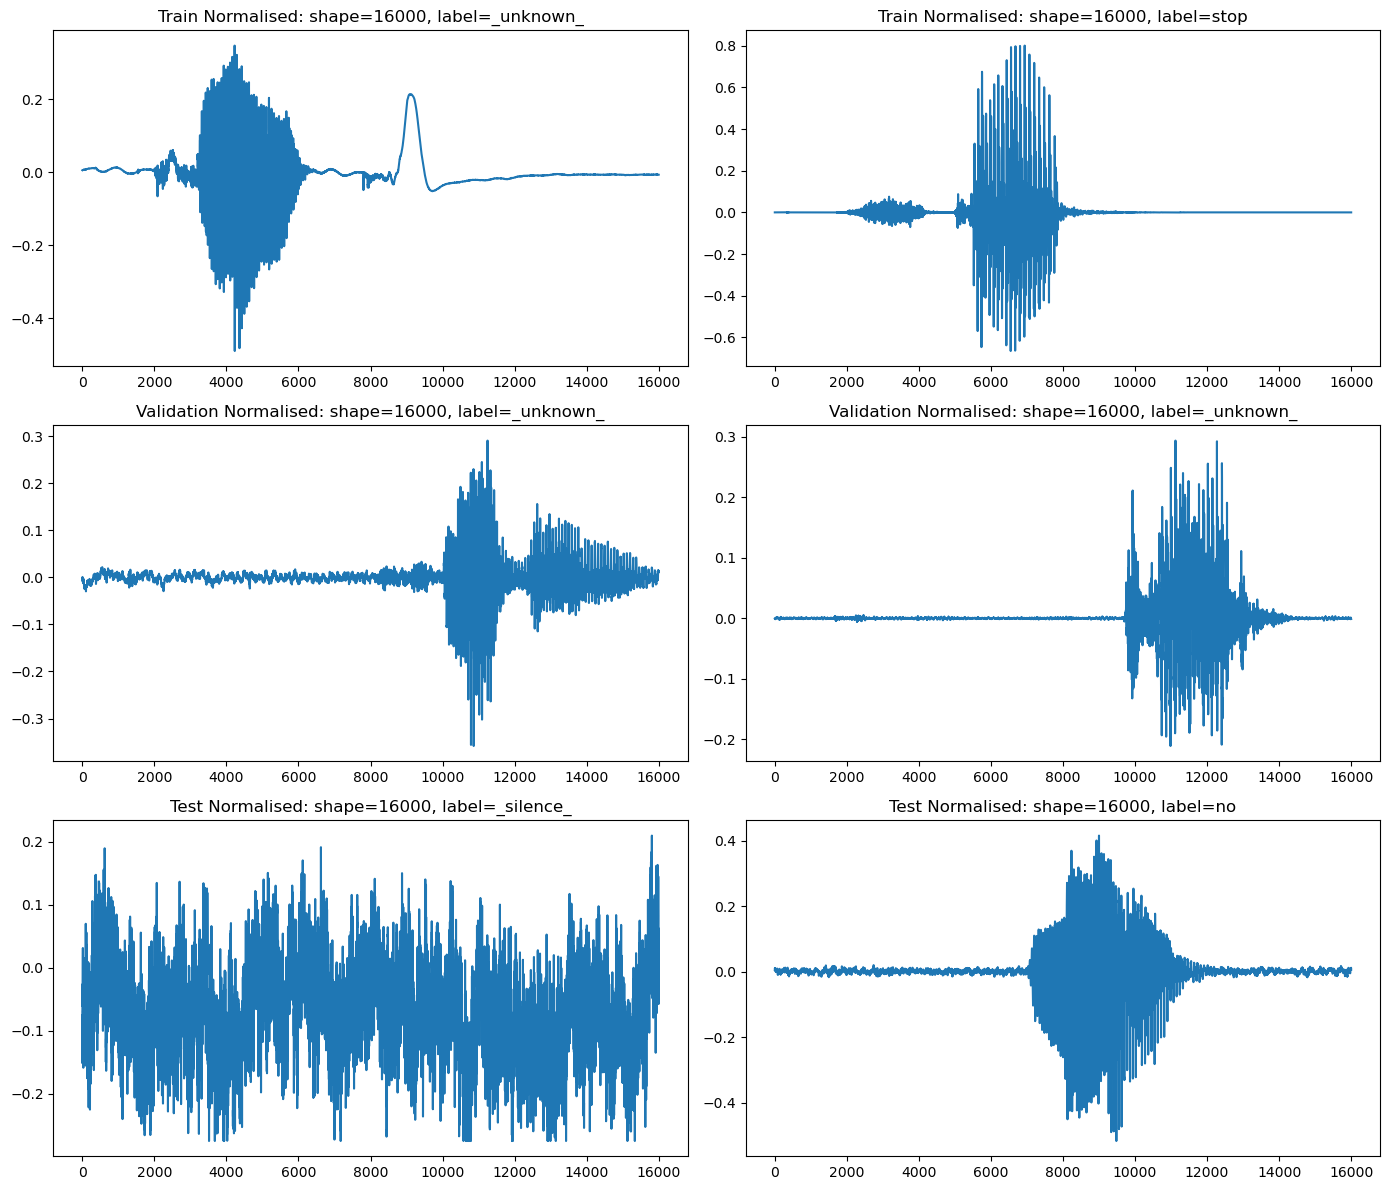

In [40]:
plot_two_samples_per_dataset(
    [train_dataset_Nor_Padded, validation_dataset_Nor_Padded, test_dataset_Nor_Padded],
    ['Train Normalised', 'Validation Normalised', 'Test Normalised'],
    label_names
)

- Verify the Dataset
To ensure everything is working as expected, let's inspect the dataset and visualize some samples:

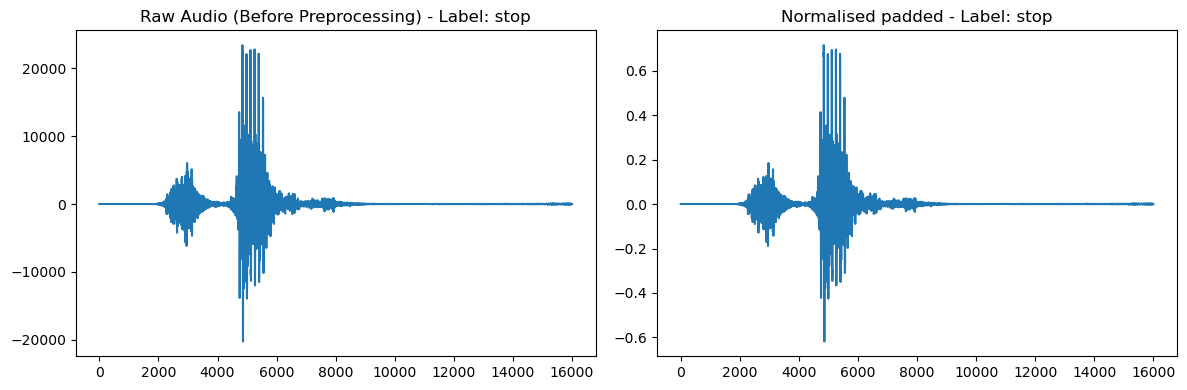

In [41]:

'''ds = tf.data.experimental.load('saved_speech_commands/train')    raw_audio, raw_label = next(iter(ds))
# Get the first raw audio sample and its label from the original dataset
raw_audio, raw_label = next(iter(ds))'''

# Get the first raw audio sample and its label from the original dataset
raw_audio, raw_label = next(iter(new_train_dataset))

# Get the first preprocessed audio sample and its label from the preprocessed dataset
preprocessed_audio, preprocessed_label = next(iter(train_dataset_Nor_Padded))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(raw_audio.numpy())
plt.title(f"Raw Audio (Before Preprocessing) - Label: {label_names[raw_label.numpy()]}")

plt.subplot(1, 2, 2)
plt.plot(preprocessed_audio.numpy())
plt.title(f"Normalised padded - Label: {label_names[preprocessed_label.numpy()]}")

plt.tight_layout()
plt.show()

### 2-2 **Prepare data for CNN**
 **Extract Features**:
   - Convert raw audio into spectrograms or MFCCs using TensorFlow's `tf.signal` module.
   - These features will serve as input to the CNN.


In [42]:
# here in this cell add short explanation in front or over each code to clarify it
# Define a function to extract MFCC features from audio
def extract_mfcc(audio, label):
    # Convert audio to float32 for processing
    audio = tf.cast(audio, tf.float32)
    # Compute the Short-Time Fourier Transform (STFT)
    stft = tf.signal.stft(audio, frame_length=514, frame_step=128)
    # Get the magnitude of the STFT (spectrogram)
    spectrogram = tf.abs(stft)
    num_spectrogram_bins = spectrogram.shape[-1] #accesses the last dimension of the shape, which is the number of frequency bins per frame
    sample_rate = 16000  # Use 16kHz sample rate as standard for this dataset
    num_mel_bins = 40

    # Create a matrix to convert the spectrogram to the mel scale
    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins, num_spectrogram_bins, sample_rate, 20, 4000
    )
    # Apply the mel filterbank to the spectrogram
    mel_spectrogram = tf.tensordot(spectrogram, linear_to_mel_weight_matrix, 1)
    mel_spectrogram.set_shape(spectrogram.shape[:-1].concatenate(linear_to_mel_weight_matrix.shape[-1:]))

    # Take the logarithm of the mel spectrogram for better feature scaling
    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)
    # Compute the MFCCs from the log-mel spectrogram
    mfccs = tf.signal.mfccs_from_log_mel_spectrograms(log_mel_spectrogram)
    # Keep only the first 13 MFCC coefficients (common practice)
    mfccs = mfccs[..., :13]
    return mfccs, label

# Map the MFCC extraction function to each dataset
train_dataset_preprocessed = train_dataset_Nor_Padded.map(extract_mfcc)
validation_dataset_preprocessed = validation_dataset_Nor_Padded.map(extract_mfcc)
test_dataset_preprocessed = test_dataset_Nor_Padded.map(extract_mfcc)

# Print shapes and a sample of MFCCs and labels from the processed train_dataset
print("Sample MFCCs and labels from train_dataset:")
for mfccs, label in train_dataset_preprocessed.take(3):
    print("MFCCs shape:", mfccs.shape)
    print("Label:", label.numpy())
    print("MFCCs sample (first frame):", mfccs[0].numpy())
    print("---")


Sample MFCCs and labels from train_dataset:
MFCCs shape: (121, 13)
Label: 7
MFCCs sample (first frame): [-43.188374    -1.8931233   -1.1336226   -0.19598712   0.62225455
   0.7664456   -0.2364308   -0.6642025   -1.3111166   -0.4783639
  -0.88651514  -1.4532084   -0.44571468]
---
MFCCs shape: (121, 13)
Label: 1
MFCCs sample (first frame): [-3.6174641e+01  3.4673784e+00  2.0706024e+00  7.7863073e-01
  1.3094977e-02  1.3132519e+00  2.1629219e+00  3.6190514e-02
 -7.7559513e-01 -9.7422377e-04  1.7205271e+00  1.0878102e+00
  5.0986886e-01]
---
MFCCs shape: (121, 13)
Label: 0
MFCCs sample (first frame): [-16.781332    11.261096     0.70722467   0.48436776   1.2147225
   0.90637046  -0.4568363   -0.7483933    0.04813326   0.7871936
  -1.422428    -0.36270377  -0.61171544]
---


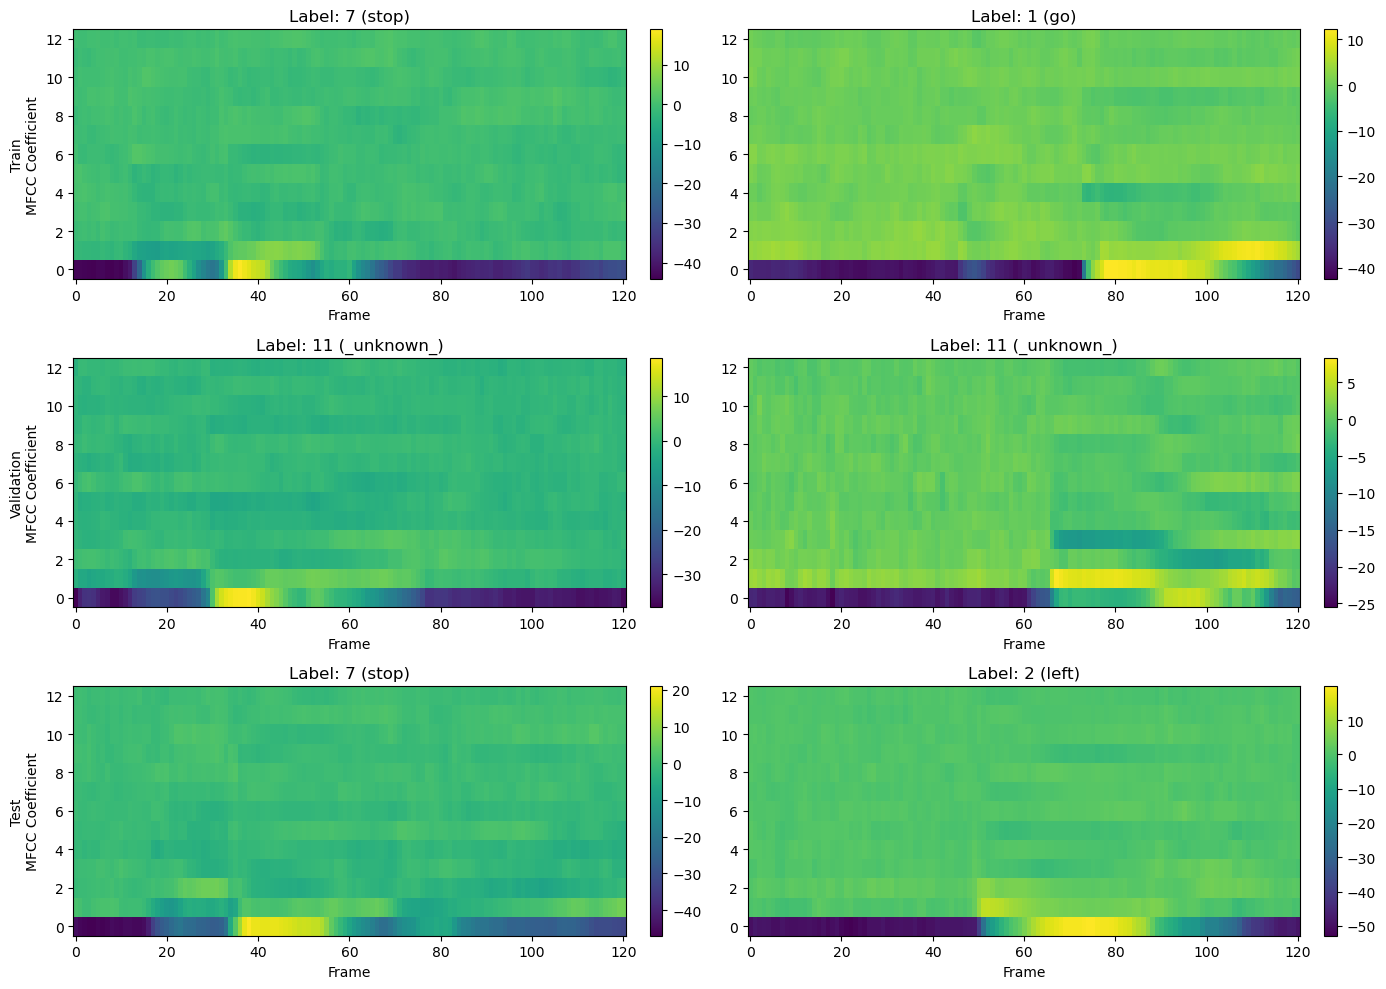

'def plot_mfcc_sample(mfccs, label, label_names=None):\n    plt.figure(figsize=(10, 4))\n    plt.imshow(mfccs.T, aspect=\'auto\', origin=\'lower\', cmap=\'viridis\')\n    plt.colorbar(label=\'MFCC Coefficient Value\')\n    plt.xlabel(\'Frame\')\n    plt.ylabel(\'MFCC Coefficient\')\n    title = f"MFCCs - Label: {label}"\n    if label_names is not None:\n        title += f" ({label_names[label]})"\n    plt.title(title)\n    plt.tight_layout()\n    plt.show()\n\n# Plot a few samples from your train_dataset\nfor mfccs, label in train_dataset_preprocessed.take(3):\n    plot_mfcc_sample(mfccs.numpy(), label.numpy(), label_names)'

In [43]:
import matplotlib.pyplot as plt
import numpy as np
fig, axs = plt.subplots(3, 2, figsize=(14, 10))

# Helper to plot MFCCs in a given axis
def plot_mfcc_on_ax(ax, mfccs, label, label_names=None):
    im = ax.imshow(mfccs.T, aspect='auto', origin='lower', cmap='viridis')
    ax.set_xlabel('Frame')
    ax.set_ylabel('MFCC Coefficient')
    title = f"Label: {label}"
    if label_names is not None:
        title += f" ({label_names[label]})"
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Plot 2 samples from each dataset
datasets = [
    ("Train", train_dataset_preprocessed),
    ("Validation", validation_dataset_preprocessed),
    ("Test", test_dataset_preprocessed)
]

for row, (name, ds) in enumerate(datasets):
    for col, (mfccs, label) in enumerate(ds.take(2)):
        plot_mfcc_on_ax(axs[row, col], mfccs.numpy(), label.numpy(), label_names)
        if col == 0:
            axs[row, col].set_ylabel(f"{name}\nMFCC Coefficient")
        else:
            axs[row, col].set_ylabel("")

plt.tight_layout()
plt.show()
'''def plot_mfcc_sample(mfccs, label, label_names=None):
    plt.figure(figsize=(10, 4))
    plt.imshow(mfccs.T, aspect='auto', origin='lower', cmap='viridis')
    plt.colorbar(label='MFCC Coefficient Value')
    plt.xlabel('Frame')
    plt.ylabel('MFCC Coefficient')
    title = f"MFCCs - Label: {label}"
    if label_names is not None:
        title += f" ({label_names[label]})"
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Plot a few samples from your train_dataset
for mfccs, label in train_dataset_preprocessed.take(3):
    plot_mfcc_sample(mfccs.numpy(), label.numpy(), label_names)'''

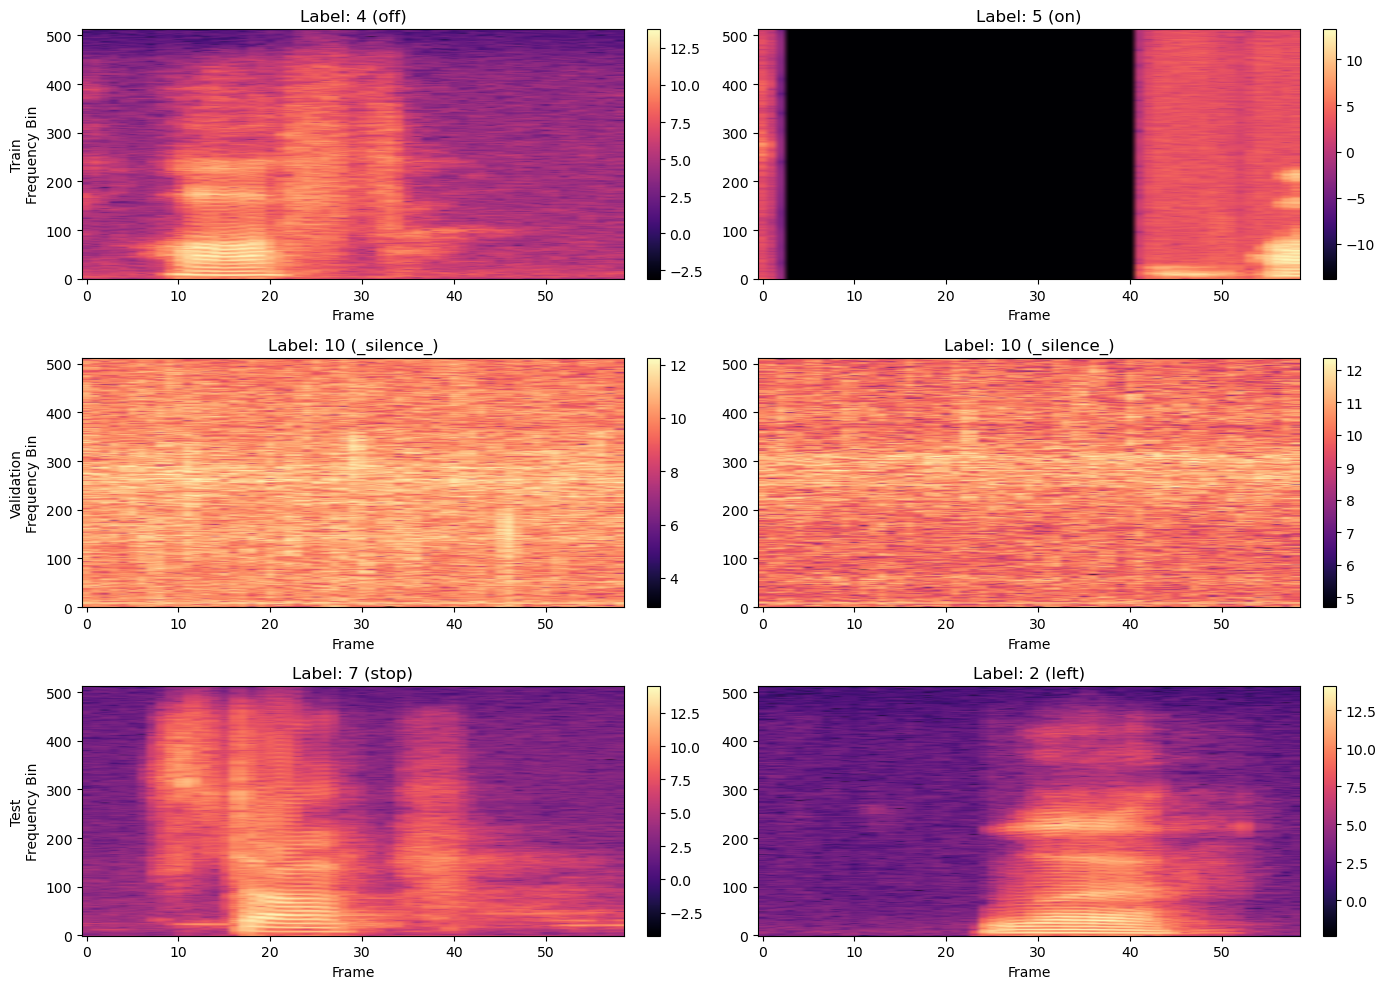

'def plot_spectrogram(spectrogram, label, label_names=None):\n    plt.figure(figsize=(10, 4))\n    plt.imshow(np.log(spectrogram.T + 1e-6), aspect=\'auto\', origin=\'lower\', cmap=\'magma\')\n    plt.colorbar(label=\'Log Magnitude\')\n    plt.xlabel(\'Frame\')\n    plt.ylabel(\'Frequency Bin\')\n    title = f"Spectrogram - Label: {label}"\n    if label_names is not None:\n        title += f" ({label_names[label]})"\n    plt.title(title)\n    plt.tight_layout()\n    plt.show()\n\n\ndef get_spectrogram(audio):\n    audio = tf.cast(audio, tf.float32)\n    stft = tf.signal.stft(audio, frame_length=1024, frame_step=256)\n    spectrogram = tf.abs(stft)\n    return spectrogram\n\nfor audio, label in train_dataset.take(3):  # Use your original (not preprocessed) dataset\n    spectrogram = get_spectrogram(audio)\n    plot_spectrogram(spectrogram.numpy(), label.numpy(), label_names)\n    import matplotlib.pyplot as plt\nimport librosa.display\n\ndef plot_spectrogram(audio, sr=16000):\n    plt.fi

In [44]:
import matplotlib.pyplot as plt

# List of datasets to plot: (name, dataset)
datasets_to_plot = [
    ("Train", train_dataset),
    ("Validation", validation_dataset),
    ("Test", test_dataset)
]

fig, axs = plt.subplots(len(datasets_to_plot), 2, figsize=(14, 10))

def plot_spectrogram_on_ax(ax, spectrogram, label, label_names=None):
    im = ax.imshow(np.log(spectrogram.T + 1e-6), aspect='auto', origin='lower', cmap='magma')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Frequency Bin')
    title = f"Label: {label}"
    if label_names is not None:
        title += f" ({label_names[label]})"
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def get_spectrogram(audio):
    audio = tf.cast(audio, tf.float32)
    stft = tf.signal.stft(audio, frame_length=1024, frame_step=256)
    spectrogram = tf.abs(stft)
    return spectrogram

for row, (name, dataset) in enumerate(datasets_to_plot):
    for col, (audio, label) in enumerate(dataset.take(2)):
        spectrogram = get_spectrogram(audio)
        plot_spectrogram_on_ax(axs[row, col], spectrogram.numpy(), label.numpy(), label_names)
        if col == 0:
            axs[row, col].set_ylabel(f"{name}\nFrequency Bin")
        else:
            axs[row, col].set_ylabel("")

plt.tight_layout()
plt.show()
'''def plot_spectrogram(spectrogram, label, label_names=None):
    plt.figure(figsize=(10, 4))
    plt.imshow(np.log(spectrogram.T + 1e-6), aspect='auto', origin='lower', cmap='magma')
    plt.colorbar(label='Log Magnitude')
    plt.xlabel('Frame')
    plt.ylabel('Frequency Bin')
    title = f"Spectrogram - Label: {label}"
    if label_names is not None:
        title += f" ({label_names[label]})"
    plt.title(title)
    plt.tight_layout()
    plt.show()


def get_spectrogram(audio):
    audio = tf.cast(audio, tf.float32)
    stft = tf.signal.stft(audio, frame_length=1024, frame_step=256)
    spectrogram = tf.abs(stft)
    return spectrogram

for audio, label in train_dataset.take(3):  # Use your original (not preprocessed) dataset
    spectrogram = get_spectrogram(audio)
    plot_spectrogram(spectrogram.numpy(), label.numpy(), label_names)
    import matplotlib.pyplot as plt
import librosa.display

def plot_spectrogram(audio, sr=16000):
    plt.figure(figsize=(10, 4))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spectrogram')
    plt.show()'''

### Data preparation
he output shape of the Conv2D layer, such as (None, 119, 11, 32), has four dimensions because Conv2D in Keras expects and produces 4D tensors:

The first dimension (None) is the batch size (number of samples processed at once; None means it can be any size).
The second dimension (119) is the height (number of frames in your MFCC input after convolution).
The third dimension (11) is the width (number of MFCC coefficients after convolution).
The fourth dimension (32) is the number of filters (channels) produced by the Conv2D layer.
This 4D shape is standard for Conv2D layers in Keras/TensorFlow, where the input and output are always (batch, height, width, channels). The extra dimension (channels/filters) allows the network to learn multiple feature maps from the input.

Adding 1 channel and chossing a batch for training:

In [45]:
# Check shape of a sample
for mfcc, _ in train_dataset_preprocessed.take(1):
    print(mfcc.shape)  # If (frames, 13), you need to add channel dim
    
def add_channel_dim(mfcc, label):
    mfcc = tf.expand_dims(mfcc, -1)
    return mfcc, label
# Only map if needed
if len(mfcc.shape) == 2:
    train_dataset_preprocessed = train_dataset_preprocessed.map(add_channel_dim)
    validation_dataset_preprocessed = validation_dataset_preprocessed.map(add_channel_dim)
    test_dataset_preprocessed = test_dataset_preprocessed.map(add_channel_dim)

# Batch, shuffle, and prefetch the datasets
# Prepare the datasets for training 
BATCH_SIZE = 32
train_dataset_batched = train_dataset_preprocessed.batch(BATCH_SIZE).shuffle(1000).prefetch(tf.data.AUTOTUNE)
validation_dataset_batched = validation_dataset_preprocessed.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset_batched = test_dataset_preprocessed.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

(121, 13)


In [46]:
print("train_dataset_batched dimention:", next(iter(train_dataset_batched))[0].shape)  # Should be (121, 13, 1)
print("validation_dataset_batched dimention:", next(iter(validation_dataset_batched))[0].shape)  # Should be (121, 13, 1)
print("test_dataset_batched dimention:", next(iter(test_dataset_batched))[0].shape)  # Should be (121, 13, 1)

train_dataset_batched dimention: (32, 121, 13, 1)
validation_dataset_batched dimention: (32, 121, 13, 1)
test_dataset_batched dimention: (32, 121, 13, 1)


Check out dimentions

In [47]:
for x, y in train_dataset_batched.take(1):
    print("Train batch shape:", x.shape, y.shape)
for x, y in validation_dataset_batched.take(1):
    print("Validation batch shape:", x.shape, y.shape)
for x, y in test_dataset_batched.take(1):
    print("Test batch shape:", x.shape, y.shape)
# x refers to the batch of input features (MFCCs with shape (batch_size, frames, coefficients, channels)).
# y refers to the batch of labels (typically shape (batch_size,), containing the class indices for each sample in the batch).

Train batch shape: (32, 121, 13, 1) (32,)
Validation batch shape: (32, 121, 13, 1) (32,)
Test batch shape: (32, 121, 13, 1) (32,)


inspect batches:

In [48]:
# Inspect the first 3 batches from each dataset
for name, dataset in [("Train", train_dataset_batched), 
                      ("Validation", validation_dataset_batched), 
                      ("Test", test_dataset_batched)]:
    print(f"\n{name} dataset:")
    for i, (x, y) in enumerate(dataset.take(3)):
        print(f"  Batch {i+1}: x.shape = {x.shape}, y.shape = {y.shape}, unique labels = {tf.unique(y)[0].numpy()}")


Train dataset:
  Batch 1: x.shape = (32, 121, 13, 1), y.shape = (32,), unique labels = [ 5  7  9 11  3  0  1  4]
  Batch 2: x.shape = (32, 121, 13, 1), y.shape = (32,), unique labels = [11  6  3  0  2  7  1]
  Batch 3: x.shape = (32, 121, 13, 1), y.shape = (32,), unique labels = [11  2  0  7  6  4  3 10]

Validation dataset:
  Batch 1: x.shape = (32, 121, 13, 1), y.shape = (32,), unique labels = [11  6  2  4  3  1  0  8  9]
  Batch 2: x.shape = (32, 121, 13, 1), y.shape = (32,), unique labels = [11  9 10  5  1  0  6  3  7]
  Batch 3: x.shape = (32, 121, 13, 1), y.shape = (32,), unique labels = [ 4  6 11  5  7  9  3  0  2]

Test dataset:
  Batch 1: x.shape = (32, 121, 13, 1), y.shape = (32,), unique labels = [ 7  2  6  8  5  0  9  4  3 11  1 10]
  Batch 2: x.shape = (32, 121, 13, 1), y.shape = (32,), unique labels = [ 6  7  5  9  1  8 11  2  3  0 10  4]
  Batch 3: x.shape = (32, 121, 13, 1), y.shape = (32,), unique labels = [ 9  3  1  7  5  8  0 10  4 11  2]


### Step 3: **Find a CNN for Keyword Spotting**

The next step is to identify a Convolutional Neural Network (CNN) architecture suitable for keyword spotting. A commonly used model for this task is based on the paper ["Convolutional Neural Networks for Small-footprint Keyword Spotting"](https://static.googleusercontent.com/media/research.google.com/en//pubs/archive/43969.pdf). This model is lightweight and designed for resource-constrained devices like microcontrollers.
 **Define the CNN Model**:
   - Use TensorFlow/Keras to define the CNN architecture.
   - compile - fit the model
   - Specify the optimizer, loss function, and evaluation metrics.




---

In [49]:
from tensorflow.keras import layers, models

# Get MFCC shape from a sample
example_mfcc_shape = next(iter(train_dataset_preprocessed.take(1)))[0].shape  # (121, 13)
input_shape = (example_mfcc_shape[0], example_mfcc_shape[1], 1)
# (121, 13, 1) to make the MFCC feature input compatible with Keras Conv2D layers, which expect a 3D input per sample: (height, width, channels)
num_classes = 12  # Set to number of labels
print(input_shape)  # Should be (121, 13, 1)
for batch in train_dataset_batched.take(1):
    print("Input batch shape:", batch[0].shape)

def create_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),  # CHANGED: Added this layer
        layers.MaxPooling2D((2, 2)),
        #layers.Flatten(),
        layers.GlobalAveragePooling2D(),  # More robust than Flatten
        layers.Dense(64, activation='relu'),  # CHANGED: Reduced from 128 to 64
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


model = create_cnn_model(input_shape, num_classes)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


(121, 13, 1)
Input batch shape: (32, 121, 13, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 119, 11, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 59, 5, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 57, 3, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 1, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,756 (92.80 KB)

 Trainable params: 23,756 (92.80 KB)

 Non-trainable params: 0 (0.00 B)

3.2: Train the Model

We will train the model using the model.fit() method and validate it on the validation dataset.



In [50]:
import time

print("Before fitting...", flush=True)
start = time.time()

history = model.fit(
    train_dataset_batched,
    validation_data=test_dataset_batched,
    epochs=20,
    verbose=1
)

print(f"Training done in {time.time() - start:.2f} seconds", flush=True)



Before fitting...
Epoch 1/20
2996/2996 ━━━━━━━━━━━━━━━━━━━━ 52s 14ms/step - accuracy: 0.6568 - loss: 1.2180 - val_accuracy: 0.5474 - val_loss: 1.3205
Epoch 2/20
2996/2996 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - accuracy: 0.8047 - loss: 0.6091 - val_accuracy: 0.7368 - val_loss: 0.7908
Epoch 3/20
2996/2996 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - accuracy: 0.8545 - loss: 0.4582 - val_accuracy: 0.7597 - val_loss: 0.7271
Epoch 4/20
2996/2996 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - accuracy: 0.8748 - loss: 0.3988 - val_accuracy: 0.7998 - val_loss: 0.6095
Epoch 5/20
2996/2996 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - accuracy: 0.8877 - loss: 0.3548 - val_accuracy: 0.8143 - val_loss: 0.5500
Epoch 6/20
2996/2996 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - accuracy: 0.8953 - loss: 0.3263 - val_accuracy: 0.8350 - val_loss: 0.4954
Epoch 7/20
2996/2996 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - accuracy: 0.9036 - loss: 0.3056 - val_accuracy: 0.8403 - val_loss: 0.4697
Epoch 8/20
2996/2996 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - 

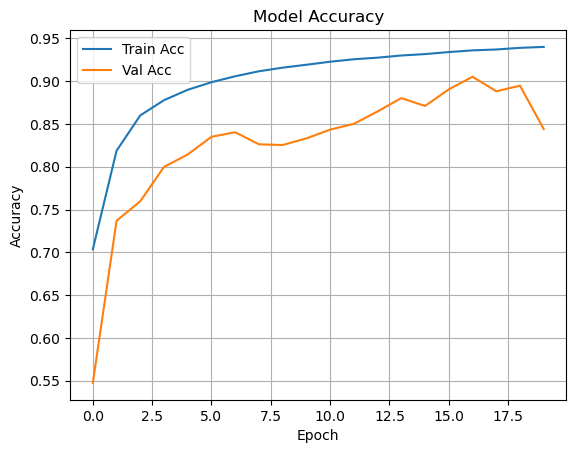

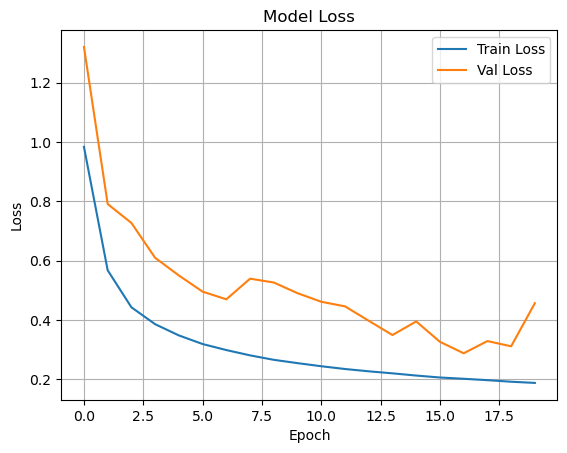

In [52]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.grid(True)
plt.show()


3.3: Evaluate the Model

After training, evaluate the model on the test dataset to measure its performance.



In [54]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_dataset_batched)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8414 - loss: 0.4496
Test Loss: 0.4565
Test Accuracy: 0.8440


### Metrics 

In [59]:
from sklearn.metrics import confusion_matrix, classification_report

# Collect all test data and labels
X_test = []
y_true = []
for x, y in test_dataset_batched:
    X_test.append(x)
    y_true.extend(y.numpy())
X_test = np.concatenate(X_test, axis=0)
y_true = np.array(y_true)

# Predict all at once (no progress bar spam)
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Print confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_names))

Confusion Matrix:
[[357   1   1   3   0   0   0   0   0   0   0  44]
 [ 15 326   2  17   0   1   0   2   1   0   0  38]
 [  0   0 392   0   0   0   1   0   0   2   0  17]
 [  6   1   1 332   0   0   0   0   0   5   0  60]
 [  0   2  12   0 271  22   0   1  13   0   0  81]
 [  0   0   0   0   3 341   0   0   4   0   0  48]
 [  0   0   4   0   0   0 344   0   0   0   0  48]
 [  5   2   0   0   0   0   0 344   1   0   0  59]
 [  0   0   5   0   3   2   0  10 324   0   0  81]
 [  1   0   6   0   0   0   0   0   0 390   0  22]
 [  5   0   0   0   0   0   0   0   0   0 303 100]
 [  2   0   3   0   0   0   0   0   0   0   0 403]]

Classification Report:
              precision    recall  f1-score   support

        down       0.91      0.88      0.90       406
          go       0.98      0.81      0.89       402
        left       0.92      0.95      0.94       412
          no       0.94      0.82      0.88       405
         off       0.98      0.67      0.80       402
          on       0

3.4: Visualize Training Results

Plot the training and validation accuracy/loss to analyze the model's performance over epochs.

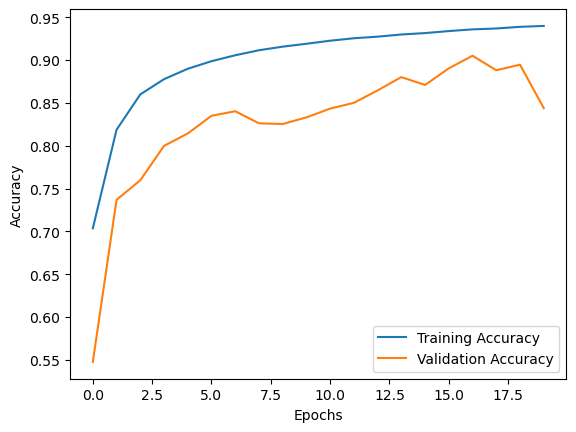

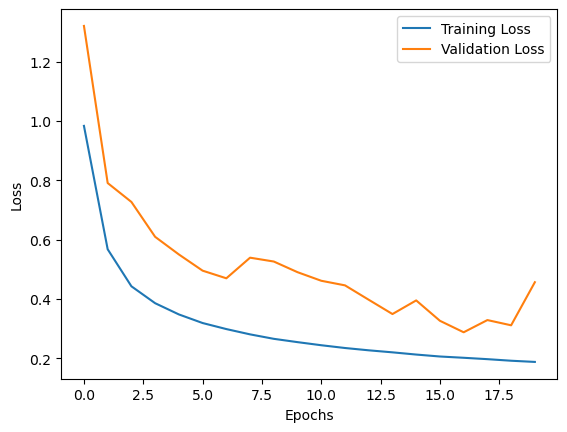

In [60]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Step 4: Post-Training Quantization

Post-training quantization is a crucial step to optimize the model for deployment on resource-constrained devices like the EFR32MG24 microcontroller. This process reduces the model size and improves inference speed by converting the model's weights from float32 to int8

### 4.1: Convert the Model to TensorFlow Lite Format

In [62]:
# Create a TFLiteConverter from your trained model
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Convert the model to TFLite format (float32)
tflite_model = converter.convert()

# Save the TFLite model to a file
with open('model_float32.tflite', 'wb') as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: C:\Users\Peyman\AppData\Local\Temp\tmps4q306vo\assets


INFO:tensorflow:Assets written to: C:\Users\Peyman\AppData\Local\Temp\tmps4q306vo\assets


Saved artifact at 'C:\Users\Peyman\AppData\Local\Temp\tmps4q306vo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 121, 13, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  1889644688160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1889643498656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1889643511504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1889643505872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1889643502704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1889643509040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1889643507632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1889642842944: TensorSpec(shape=(), dtype=tf.resource, name=None)


### 4.2: Apply Post-Training Quantization

To quantize the model, we will use TensorFlow Lite's post-training quantization feature. This converts the weights to int8



In [67]:
# Apply post-training quantization with a representative dataset

def representative_data_gen():
    for audio, _ in train_dataset_Nor_Padded.take(100):  # Use 100 samples for calibration
        # Extract MFCCs as in training
        mfccs, _ = extract_mfcc(audio, _)
        mfccs = tf.expand_dims(mfccs, -1)  # Add channel dimension
        mfccs = tf.expand_dims(mfccs, 0)   # Add batch dimension
        yield [mfccs]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_types = [tf.int8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

quantized_tflite_model = converter.convert()

with open('model_int8.tflite', 'wb') as f:
    f.write(quantized_tflite_model)

print("Model quantized to int8 and saved as 'model_int8.tflite'.")

INFO:tensorflow:Assets written to: C:\Users\Peyman\AppData\Local\Temp\tmpcye4qc4n\assets


INFO:tensorflow:Assets written to: C:\Users\Peyman\AppData\Local\Temp\tmpcye4qc4n\assets


Saved artifact at 'C:\Users\Peyman\AppData\Local\Temp\tmpcye4qc4n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 121, 13, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  1889644688160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1889643498656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1889643511504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1889643505872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1889643502704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1889643509040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1889643507632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1889642842944: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\Peyman\.conda\envs\ml-SiliconLab\lib\site-packages\tensorflow\lite\python\convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Model quantized to int8 and saved as 'model_int8.tflite'.


### 4.3: Verify the Quantized Model

To ensure the quantized model works as expected, we can test it by running inference on some test samples and comparing the results with the original model.
iputs and ouputs both should be int8



In [69]:
import warnings
warnings.filterwarnings("ignore")

interpreter = tf.lite.Interpreter(model_path='model_int8.tflite')
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input dtype:", input_details[0]['dtype'])
print("Output dtype:", output_details[0]['dtype'])
print("Input shape:", input_details[0]['shape'])

Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input shape: [  1 121  13   1]


In [74]:
# Load the quantized model
interpreter = tf.lite.Interpreter(model_path='model_int8.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test the quantized model on a single test sample
for audio, label in test_dataset.take(10):
    # 1. Normalize
    audio = tf.cast(audio, tf.float32) / tf.int16.max
    # 2. Extract MFCCs
    mfccs, _ = extract_mfcc(audio, label)
    # 3. Add channel dimension
    mfccs = tf.expand_dims(mfccs, -1)
    # 4. Add batch dimension
    mfccs = tf.expand_dims(mfccs, 0)
    # 5. Quantize to int8 using input scale/zero_point
    input_scale, input_zero_point = input_details[0]['quantization']
    mfccs_int8 = np.round(mfccs.numpy() / input_scale + input_zero_point).astype(np.int8)
    # 6. Set tensor and run inference
    interpreter.set_tensor(input_details[0]['index'], mfccs_int8)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    print("Raw output:", output_data)
    print(f"Predicted: {tf.argmax(output_data)}, Actual: {label.numpy()}")

Raw output: [[-128 -128 -128 -128 -128 -128 -128  115 -128 -128 -128 -116]]
Predicted: [0 0 0 0 0 0 0 0 0 0 0 0], Actual: 7
Raw output: [[-128 -128  127 -128 -128 -128 -128 -128 -128 -127 -128 -128]]
Predicted: [0 0 0 0 0 0 0 0 0 0 0 0], Actual: 2
Raw output: [[-128 -128 -128 -128 -128 -128  126 -128 -128 -128 -128 -126]]
Predicted: [0 0 0 0 0 0 0 0 0 0 0 0], Actual: 6
Raw output: [[-128 -128 -128 -128 -125 -127 -128 -128  123 -128 -128 -127]]
Predicted: [0 0 0 0 0 0 0 0 0 0 0 0], Actual: 8
Raw output: [[-128 -128 -128 -128 -128  127 -128 -128 -128 -128 -128 -128]]
Predicted: [0 0 0 0 0 0 0 0 0 0 0 0], Actual: 5
Raw output: [[ 123 -128 -128 -128 -128 -128 -128 -128 -128 -128 -128 -124]]
Predicted: [0 0 0 0 0 0 0 0 0 0 0 0], Actual: 0
Raw output: [[-128 -128 -128 -128  -95 -128 -128 -128   92 -128 -128 -126]]
Predicted: [0 0 0 0 0 0 0 0 0 0 0 0], Actual: 8
Raw output: [[-128 -128 -128 -128 -128 -128 -128 -128 -128  127 -128 -128]]
Predicted: [0 0 0 0 0 0 0 0 0 0 0 0], Actual: 9
Raw outp

Step 5: Deploy the Model on the Microcontroller

Now that the model has been quantized and saved in TensorFlow Lite format (model_int8.tflite), the next step is to deploy it on the Silicon Labs EFR32MG24 microcontroller using Simplicity Studio.

5.1: Set Up Simplicity Studio
Install Simplicity Studio:

Ensure you have Simplicity Studio installed on your machine. You can download it from Silicon Labs' website.
Install Required Tools:

Install the Gecko SDK and the Machine Learning Toolkit within Simplicity Studio.
Connect the EFR32MG24 Kit:

Connect your EFR32MG24 development kit to your computer via USB.
Ensure the kit is detected in Simplicity Studio.
5.2: Import the TensorFlow Lite Model
Prepare the Model:

Copy the model_int8.tflite file to your project directory in Simplicity Studio.
Follow the Silicon Labs Guide:

Refer to the Getting Started with Machine Learning guide from Silicon Labs.
Use the TensorFlow Lite Micro (TFLM) library to integrate the model into your project.
Add the Model to the Project:

Add the model_int8.tflite file to your Simplicity Studio project.
Use the tensorflow_lite_micro library to load and run the model on the microcontroller.
5.3: Run Inference on the Microcontroller
Write Code to Load the Model:

Use the TensorFlow Lite Micro API to load the model and allocate memory for inference.
Test the Model:

Write a test program to feed sample inputs to the model and verify the outputs.
Compare the results of the model running on the microcontroller with the results from your Python implementation.

KWS-exampleCocdeMicro.cpp

5.4: Verify the Model

Deploy the program to the EFR32MG24 microcontroller.
Run the program and verify that the model produces correct outputs for test inputs.
Compare the results with the Python implementation to ensure consistency.



# Convert the model.
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model.
with open('model.tflite', 'wb') as f:
  f.write(tflite_model)